In [5]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [6]:
batch_size = 32
IMG_SIZE = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    "/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Dataset/train",
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    "/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Dataset/val",
    target_size=IMG_SIZE,
    batch_size=batch_size,
    class_mode="categorical"
)


Found 4835 images belonging to 3 classes.
Found 1031 images belonging to 3 classes.


In [7]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [8]:
for layer in base_model.layers[:-60]:
    layer.trainable = False

for layer in base_model.layers[-60:]:
    layer.trainable = True


In [9]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
Dense(512, activation="relu"),
Dropout(0.6),
Dense(256, activation="relu"),
Dropout(0.5)

x = Dropout(0.5)(x)
output = Dense(3, activation="softmax")(x)  # covid, normal, pneumonia

model = Model(inputs=base_model.input, outputs=output)

In [11]:
import tensorflow as tf
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)


In [12]:
EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)


In [13]:
model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks   # ✅ AGAIN HERE
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 969ms/step - accuracy: 0.3667 - loss: 1.5472
Epoch 1: val_accuracy improved from None to 0.73230, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.4457 - loss: 1.3544 - val_accuracy: 0.7323 - val_loss: 0.7505 - learning_rate: 1.0000e-05
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6012 - loss: 0.9481
Epoch 2: val_accuracy improved from 0.73230 to 0.80989, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.6420 - loss: 0.8950 - val_accuracy: 0.8099 - val_loss: 0.5974 - learning_rate: 1.0000e-05
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7078 - loss: 0.7860
Epoch 3: val_accuracy improved from 0.80989 to 0.83414, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.7247 - loss: 0.7552 - val_accuracy: 0.8341 - val_loss: 0.5472 - learning_rate: 1.0000e-05
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7589 - loss: 0.7058
Epoch 4: val_accuracy improved from 0.83414 to 0.85063, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.7632 - loss: 0.6869 - val_accuracy: 0.8506 - val_loss: 0.5225 - learning_rate: 1.0000e-05
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7897 - loss: 0.6490
Epoch 5: val_accuracy improved from 0.85063 to 0.86421, saving model to best_model.h5


...


Epoch 6: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.8074 - loss: 0.6078 - val_accuracy: 0.8797 - val_loss: 0.4837 - learning_rate: 1.0000e-05
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8265 - loss: 0.5883
Epoch 7: val_accuracy improved from 0.87973 to 0.88458, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.8267 - loss: 0.5816 - val_accuracy: 0.8846 - val_loss: 0.4702 - learning_rate: 1.0000e-05
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8226 - loss: 0.5903
Epoch 8: val_accuracy improved from 0.88458 to 0.88555, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.8296 - loss: 0.5757 - val_accuracy: 0.8855 - val_loss: 0.4627 - learning_rate: 1.0000e-05
Epoch 9/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8356 - loss: 0.5619
Epoch 9: val_accuracy improved from 0.88555 to 0.89622, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.8391 - loss: 0.5583 - val_accuracy: 0.8962 - val_loss: 0.4505 - learning_rate: 1.0000e-05
Epoch 10/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8595 - loss: 0.5310
Epoch 10: val_accuracy improved from 0.89622 to 0.90495, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.8511 - loss: 0.5438 - val_accuracy: 0.9049 - val_loss: 0.4417 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.


In [14]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-40:]:  # last dense block
    layer.trainable = True


In [15]:
loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)


In [16]:
model.compile(
    optimizer=Adam(1e-5),
    loss=loss,
    metrics=["accuracy"]
)



In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0091838864537674), 1: np.float64(0.9954704550133827), 2: np.float64(0.9954704550133827)}


In [18]:
model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8416 - loss: 0.6625
Epoch 1: val_accuracy improved from 0.90495 to 0.90786, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.8459 - loss: 0.6591 - val_accuracy: 0.9079 - val_loss: 0.5449 - learning_rate: 1.0000e-05
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8554 - loss: 0.6449
Epoch 2: val_accuracy did not improve from 0.90786
152/152 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.8575 - loss: 0.6293 - val_accuracy: 0.9079 - val_loss: 0.5364 - learning_rate: 1.0000e-05
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8575 - loss: 0.6266
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy improved from 0.90786 to 0.91174, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.8608 - loss: 0.6261 - val_accuracy: 0.9117 - val_loss: 0.5271 - learning_rate: 1.0000e-05
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8493 - loss: 0.6455
Epoch 4: val_accuracy improved from 0.91174 to 0.91368, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.8480 - loss: 0.6323 - val_accuracy: 0.9137 - val_loss: 0.5248 - learning_rate: 3.0000e-06
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8501 - loss: 0.6299
Epoch 5: val_accuracy improved from 0.91368 to 0.91465, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.8579 - loss: 0.6152 - val_accuracy: 0.9146 - val_loss: 0.5220 - learning_rate: 3.0000e-06
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    "/Users/kpvarma/PycharmProjects/Chest_X_Rays_Pnemonia_3/Dataset/test",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False   # IMPORTANT for correct labels
)


Found 1036 images belonging to 3 classes.


In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))


65/65 ━━━━━━━━━━━━━━━━━━━━ 45s 676ms/step
              precision    recall  f1-score   support

       covid       0.72      0.99      0.83       340
      normal       0.92      0.60      0.73       348
   pneumonia       0.89      0.88      0.88       348

    accuracy                           0.82      1036
   macro avg       0.84      0.82      0.81      1036
weighted avg       0.84      0.82      0.81      1036



In [21]:
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True


In [22]:
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [23]:
model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8489 - loss: 0.6412
Epoch 1: val_accuracy did not improve from 0.91465
152/152 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.8469 - loss: 0.6423 - val_accuracy: 0.9059 - val_loss: 0.5394 - learning_rate: 5.0000e-06
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8487 - loss: 0.6345
Epoch 2: val_accuracy did not improve from 0.91465
152/152 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.8529 - loss: 0.6268 - val_accuracy: 0.9059 - val_loss: 0.5356 - learning_rate: 5.0000e-06
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8588 - loss: 0.6353
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.

Epoch 3: val_accuracy did not improve from 0.91465
152/152 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.8529 - loss: 0.6372 - val_accuracy: 0.9079 - val_loss: 0.5330 - learning_rate: 5.0000e-06
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8534 - loss

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

65/65 ━━━━━━━━━━━━━━━━━━━━ 58s 860ms/step
              precision    recall  f1-score   support

       covid       0.73      0.98      0.83       340
      normal       0.92      0.61      0.73       348
   pneumonia       0.89      0.88      0.88       348

    accuracy                           0.82      1036
   macro avg       0.84      0.82      0.82      1036
weighted avg       0.85      0.82      0.82      1036



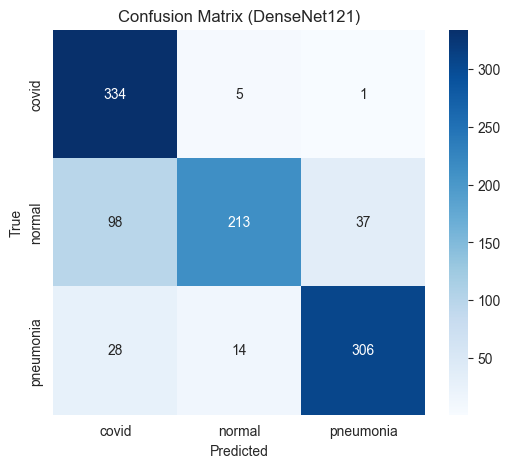

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_gen.class_indices.keys(),
    yticklabels=test_gen.class_indices.keys()
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (DenseNet121)")
plt.show()
